### EDA + Time-Series Feature Engineering

In [1]:
import pandas as pd
from sqlalchemy import create_engine
from urllib.parse import quote_plus
import os
from dotenv import load_dotenv

In [2]:

load_dotenv()
user = os.getenv("MYSQL_USER")
password = quote_plus(os.getenv("MYSQL_PASSWORD"))
host = os.getenv("MYSQL_HOST")
db = os.getenv("MYSQL_DB")

engine = create_engine(f"mysql+pymysql://{user}:{password}@{host}/{db}")

df = pd.read_sql("SELECT * FROM sales_clean", con=engine)
print(df.shape)
df.head()

(805549, 10)


,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,source_sheet,total_sales
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,Year 2009-2010,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Year 2009-2010,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Year 2009-2010,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,Year 2009-2010,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,Year 2009-2010,30.0


country
United Kingdom    1.472315e+07
EIRE              6.216311e+05
Netherlands       5.542323e+05
Germany           4.312625e+05
France            3.552575e+05
Australia         1.699681e+05
Spain             1.091785e+05
Switzerland       1.003653e+05
Sweden            9.154972e+04
Denmark           6.986219e+04
Name: total_sales, dtype: float64

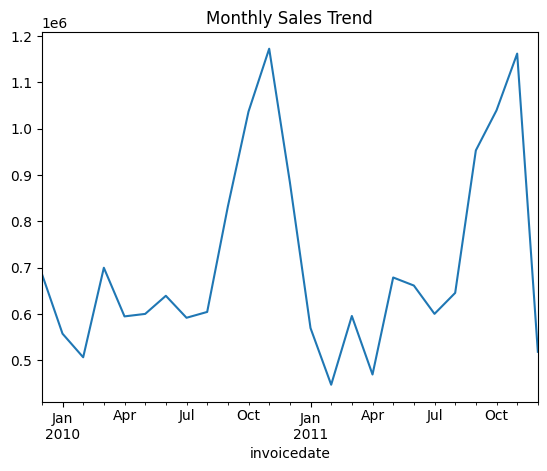

In [3]:
# Top 10 selling products by revenue
df.groupby("description")["total_sales"].sum().sort_values(ascending=False).head(10)

# Sales trend over time
df["invoicedate"] = pd.to_datetime(df["invoicedate"])
df.set_index("invoicedate")["total_sales"].resample("ME").sum().plot(title="Monthly Sales Trend")

# Top countries by sales
df.groupby("country")["total_sales"].sum().sort_values(ascending=False).head(10)

In [4]:
daily_demand = (
    df.groupby(["stockcode", "description", pd.Grouper(key="invoicedate", freq="D")])
    ["quantity"].sum()
    .reset_index()
    .rename(columns={"quantity": "daily_qty"})
)

print(daily_demand.shape)
daily_demand.head()

(440802, 4)


,stockcode,description,invoicedate,daily_qty
0,10002,INFLATABLE POLITICAL GLOBE,2009-12-01,12
1,10002,INFLATABLE POLITICAL GLOBE,2009-12-03,7
2,10002,INFLATABLE POLITICAL GLOBE,2009-12-04,73
3,10002,INFLATABLE POLITICAL GLOBE,2009-12-06,49
4,10002,INFLATABLE POLITICAL GLOBE,2009-12-07,2


In [5]:
# Keep products that appear on at least 60 different days
product_counts = daily_demand.groupby("stockcode")["invoicedate"].count()
valid_products = product_counts[product_counts >= 60].index

daily_demand = daily_demand[daily_demand["stockcode"].isin(valid_products)]
print(daily_demand["stockcode"].nunique(), "products kept")

2169 products kept


In [6]:
daily_demand["day_of_week"] = daily_demand["invoicedate"].dt.dayofweek
daily_demand["month"] = daily_demand["invoicedate"].dt.month
daily_demand["day"] = daily_demand["invoicedate"].dt.day

# Lag features: yesterday's and last week's demand
daily_demand = daily_demand.sort_values(["stockcode", "invoicedate"])
daily_demand["lag_1"] = daily_demand.groupby("stockcode")["daily_qty"].shift(1)
daily_demand["lag_7"] = daily_demand.groupby("stockcode")["daily_qty"].shift(7)

# Rolling 7-day average (smooths noise, strong predictor)
daily_demand["rolling_mean_7"] = daily_demand.groupby("stockcode")["daily_qty"].transform(lambda x: x.rolling(7, min_periods=1).mean())

daily_demand = daily_demand.dropna(subset=["lag_1", "lag_7"])
daily_demand.head()

,stockcode,description,invoicedate,daily_qty,day_of_week,month,day,lag_1,lag_7,rolling_mean_7
7,10002,INFLATABLE POLITICAL GLOBE,2009-12-14,36,0,12,14,9.0,12.0,26.857143
8,10002,INFLATABLE POLITICAL GLOBE,2009-12-21,12,0,12,21,36.0,7.0,27.571429
9,10002,INFLATABLE POLITICAL GLOBE,2009-12-23,1,2,12,23,12.0,73.0,17.285714
10,10002,INFLATABLE POLITICAL GLOBE,2010-01-04,3,0,1,4,1.0,49.0,10.714286
11,10002,INFLATABLE POLITICAL GLOBE,2010-01-08,12,4,1,8,3.0,2.0,12.142857


In [7]:
daily_demand.to_sql("daily_demand_features", con=engine, if_exists="replace", index=False)
print("Feature table pushed")

Feature table pushed
